# Task 1 · Definition of the business problem and dataset

This work analyzes a case of predictive maintenance applied to an industrial machine, with the objective of anticipating failures within a 24-hour horizon. The context is set in a production environment where a machine operates continuously and is monitored by condition and process sensors.

The dataset used is `predictive_maintenance_v3.csv`, sourced from [Kaggle](https://www.kaggle.com/datasets/tatheerabbas/industrial-machine-predictive-maintenance). The dataset simulates the collection of temporal readings from multiple machines, along with information about their operational status, environmental conditions, and variables related to wear and proximity to failure.

From a business perspective, the phenomenon to be predicted is the occurrence of a machine failure within the next 24 hours, represented by the target variable `failure_within_24h`. This allows for the planning of preventive or corrective maintenance interventions with less impact on production.

In short, we will build a multivariate model that, based on machine condition variables and operational context, estimates the probability of a failure occurring within the following 24 hours, to support predictive maintenance decisions and operational risk management.

# Task 2 · Selection and justification of candidate variables

To predict the binary variable `failure_within_24h`, we chose `vibration_rms`, `hours_since_maintenance` and `temperature_motor`. These three variables are considered especially relevant due to their direct relationship with the physical deterioration of the machine and known failure processes in industrial maintenance.

Since `current phase_avg` is strongly correlated with `pressure_level`, `rpm` and `vibration_rms`, the trends of these variables are approximately captured among each other; furthermore, it is expected that the mechanical characteristics of the machine are related to the current in direct proportion. Therefore, we chose to use only one of them in the model. In particular, we also chose `vibration_rms` because between the two, it is the one with the highest correlation (0.35 versus 0.18 for current) with the target variable, both with modest correlation values.

Furthermore, observing the distributions of the numerical variables depending on whether they fail or not, those that have more numerous groups of data where more alerts than normal are triggered are precisely `vibration_rms`, `hours_since_maintenance` and `temperature_motor`. In particular, the trend is that if these values increase, the probability of failure increases. This also happens with `vibration_rms` but with a smaller size of groups with more failures. Therefore, between this and the current variable, we chose the latter. That is, in these variables the distribution of failures is shifted to the right, in the highest values of the variables, where they can be the majority class. Another reason that supports choosing hours is that it is the third variable with the highest correlation (0.18) with the target variable, slightly surpassing current (0.15).

Taking into account the context of the problem, we can also expect certain variables to clearly support failure. For example, high vibration (`vibration_rms`) is usually associated with misalignments, clearances, imbalances, or bearing failures; motor temperature (`temperature_motor`) reflects the thermal efficiency of the system, a sustained increase can indicate overload, ventilation problems, or internal wear, which increase the risk of thermal or electrical failure; hours since the last maintenance (`hours_since_maintenance`) quantify the accumulated exposure of the machine without preventive interventions, so as this variable increases, the risk of small defects transforming into critical failures increases.

We must take into account what the variables tell us about the problem to avoid or reduce it, so that each variable is directly linked to business decisions. Specifically, identifying the thresholds of the variables most purely related to the physical state of the machines (such as the selected ones, `vibration_rms` or `temperature_motor`) from which it begins to be more likely to fail, allows establishing preventive maintenance policies based on evidence. On the other hand, `hours_since_maintenance` serves to optimize the planning of preventive maintenance, adjusting the frequency of interventions according to the observed relationship between accumulated hours and probability of failure.

Integrated into a predictive model, these variables allow prioritizing machines and intervention times according to their estimated risk of failure in the next 24 hours. This translates into better management of maintenance resources, fewer unplanned stoppages, and finer control of costs associated with repair and loss of production.

# Task 3 · Utility of variables to understand and predict failure

The variables `vibration_rms`, `temperature_motor` and `hours_since_maintenance` provide complementary information on the degradation of the machine's state. The combination of these variables in the model allows capturing situations in which the risk of failure increases significantly, especially when high vibration is observed, temperatures above the usual ranges, and a long period since the last maintenance. These thresholds are perfectly visible in the data distribution. Vibration and temperature give us very relevant and pertinent information on the physical state of the machine. For its part, the time elapsed since the last maintenance can be seen as an auxiliary variable that, while different from the physical state of the machine, provides valuable information that directly impacts the planning of failure prevention and the optimization of costs and organization for this purpose.

From the business point of view, the analysis is linked to specific decisions, such as the optimization of maintenance resources so that the bulk of it is carried out in periods of low demand, demand forecasting and production planning, that is, adjusting the workload and operation schedule to minimize the cost of maintenance, and in the same line estimating the economic impact of different maintenance policies based on the expected repair cost and the probability of failure. Specific data on the values of the variables from which machines start to fail would give us the ability to choose to innovate in cooling systems that would prevent machines from reaching said temperature values, establish optimal stoppage periods to prevent vibrations from accelerating, even invest in materials that can withstand these vibrations without degrading, and stagger or distribute machine maintenance over time according to the time from which failures are most likely.

# Task 4 · Construction and statistical evaluation of the model

To evaluate the model's ability to explain and predict the target variable `failure_within_24h`, a logistic regression is built, taking as predictors the variables `vibration_rms`, `temperature_motor` and `hours_since_maintenance`.

Logistic regression allows modeling the probability of failure within 24 hours as a function of the selected continuous variables to which a weight is assigned. The metrics used to evaluate the model are: Recall (because we want to avoid a complete and unforeseen machine failure), F1-score (imbalanced classes and we want to keep good precision and recall), MCC (for imbalanced classes it is a good metric), likelihood, and entropy.

The metrics obtained indicate a consistent model for how basic it is, but highly improvable. As an alternative to ROC-AUC, we have the MCC which is 0.4, which is not excellent but gives sufficient signs of a model that could scale with better resources. The Recall (0.34) and F1-score (0.47) values are not excellent either; in fact, in clinical contexts, for example, a recall of more than 0.9 is expected while maintaining considerable precision. This is natural due to the choice of taking three variables; if we take more, we actually get better results. In fact, taking those three plus current, rpm and pressure, the MCC increases to 0.76, the F1-score to 0.79 and the recall to 0.75.

From the likelihood perspective, models can be compared using the log-likelihood that provides representable data. A model with higher likelihood is considered better fitted to the data, more likely, which is positive as long as excessive overfitting is not incurred. For its part, entropy provides information on the uncertainty associated with the model's predictions. In the context of binary classification, the entropy of the prediction probabilities reflects how confident the model is: highly concentrated distributions (probabilities close to 0 or 1) generate low entropy (that is, low uncertainty because the model in that case is practically deterministic), while predictions close to 0.5 probability indicate high uncertainty. This concept allows identifying regions of the variable space where the model is less reliable, pointing out cases where additional measurements or more complex models might be necessary.
In our case, the entropy is 0.42, which is quite far from 1 (something we want to avoid because it indicates total uncertainty), but it is not very close to 0, although closer to 0 than to 1. If, as argued before, we increase the variables, we obtain an entropy of 0.2 and a log-likelihood of -239, much better data.

We could have tried training with other models, but first we would lose explainability, and second we would obtain worse results with current data because we do not have as much data or variables as more complex models can process to learn better (since complexity usually implies a hunger for data).

In business terms, evaluation metrics help decide whether the model is robust enough to be incorporated into real maintenance and planning processes without incurring a cost in the long run due to inefficiencies. For example, a high sensitivity in failure detection may be a priority to minimize critical stoppages, even at the cost of accepting a higher number of false positives if the additional inspection cost is affordable.

# Task 5 · Risks, biases and limitations of the model

If a key variable changes abruptly, we can find the answer in the model's coefficients. In our case, we obtain that vibrations have a weight of 0.1, temperature of 1.4 and hours of 0.5, so an abrupt change in vibrations would not have as much impact as one in temperature, which would surely trigger the alarms. However, these coefficients are adjusted taking into account the global nature of the data they are fed with, so if this change is not a change approximately contemplated in the data distribution, it may end up not reflecting a real situation. This is more evident with maintenance hours, since even if a machine has many hours, it does not necessarily have to fail, much less if the rest of the variables are in a safe range.

As for biases, several possible ones are identified:

- Selection bias: the dataset may be built from specific periods of operation or specific machines, which limits generalization to other industrial environments or machines, so retraining would be required for each new circumstance of this nature.
- Data quality bias: the presence of missing values and the possible lack of sensor calibration introduce noise and systematic errors.
- Contextual bias: the model is trained in a specific context of operation, shifts and maintenance policy, so applying the model in a different context (for example, with other maintenance strategies or workloads) may produce less reliable predictions.

Among the limitations for real decision-making, the following stand out:

- The model captures relationships observed in historical data, but does not guarantee strong causality. Therefore, changes in the maintenance policy can alter the observed patterns.
- The target variable `failure_within_24h` depends on the definition of "failure" and the recording criteria, so if these change, the model must be recalibrated.

As additional checks before using the model in real maintenance decisions, it is recommended to:

- Perform robust cross-validation and, if possible, temporal validation (train on one interval and validate on another) to ensure stability.
- Analyze the model's sensitivity to variations in key variables (e.g., simulating vibration and temperature scenarios) to understand its behavior.
- Periodically review the model with new observations, incorporating a continuous learning or recalibration process.

# Task 6 · Exploratory visualization of variable relationships

As mentioned when selecting the variables, extreme values of them cause the proportion of failures to increase above non-failures. It has also been discussed how the characteristics and physical state of the machine have some correlation with each other, which makes sense if we view them as a consequence of the electricity feeding the machine, which is also captured by the `current_phase_avg` variable.

Regarding dispersion, as expected from the obtained correlations, no patterns or trends are observed when any physical variable is plotted against hours, but there are some when physical variables like vibrations and temperature are plotted against each other, although slight and with point clouds.

Note: A large part of this analysis was developed during the work as it was necessary to understand it and make decisions to advance.

# Task 7 · Extensions and additional concepts

As already mentioned in the limitations, abrupt changes can lead to anomalous prediction errors that the model cannot capture, but this is basically easily solvable thanks to time series. For example, keeping the same variables but duplicating them to add their state moments before.

# Annex. Python code executed with visual support for the analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    matthews_corrcoef, log_loss
)
from scipy.stats import entropy


Shape del dataset tras filtrar CNC y eliminar columnas: (5937, 7)

Columnas disponibles:
['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'failure_within_24h']

Conteo de valores nulos por columna:
vibration_rms              240
temperature_motor          189
current_phase_avg          154
pressure_level             212
rpm                        124
hours_since_maintenance      0
failure_within_24h           0
dtype: int64

Estadísticos descriptivos:
       vibration_rms  temperature_motor  current_phase_avg  pressure_level  \
count    5697.000000        5748.000000        5783.000000     5725.000000   
mean        2.050376          54.753812          10.155329       51.216611   
std         1.289482           9.888595           5.738319       28.123427   
min         0.700000          40.000000           4.000000       14.600000   
25%         0.900000          46.667500           4.960000       23.400000   
50%         2

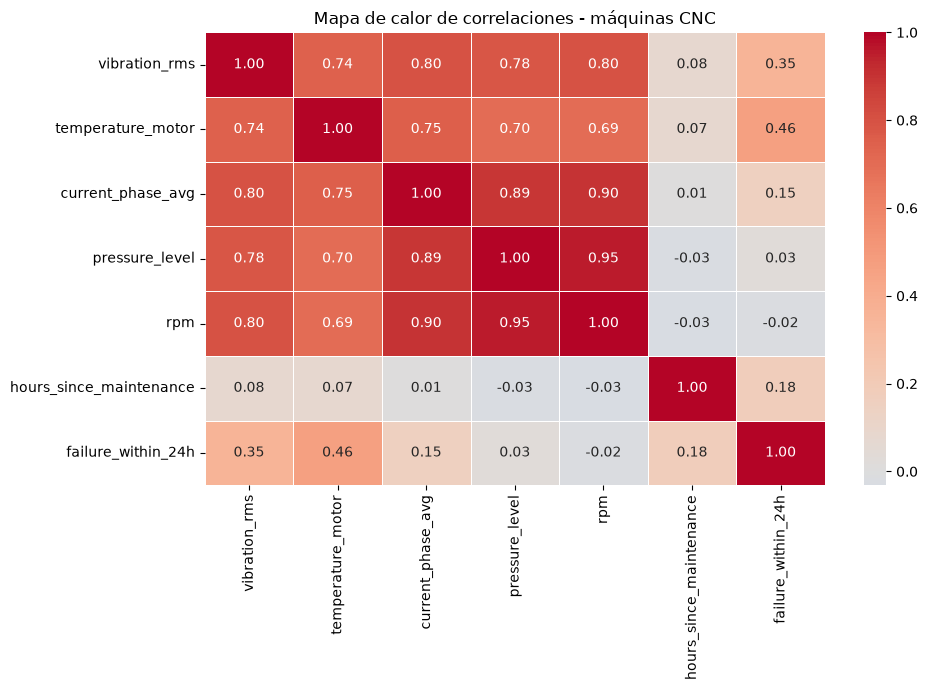

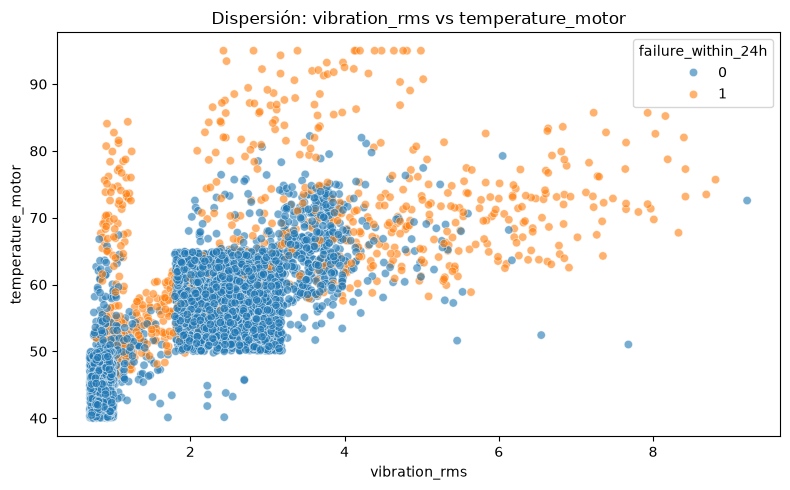

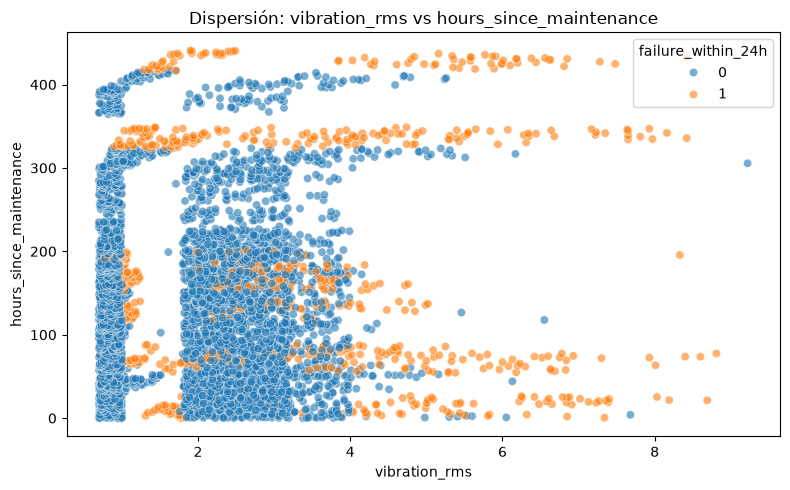

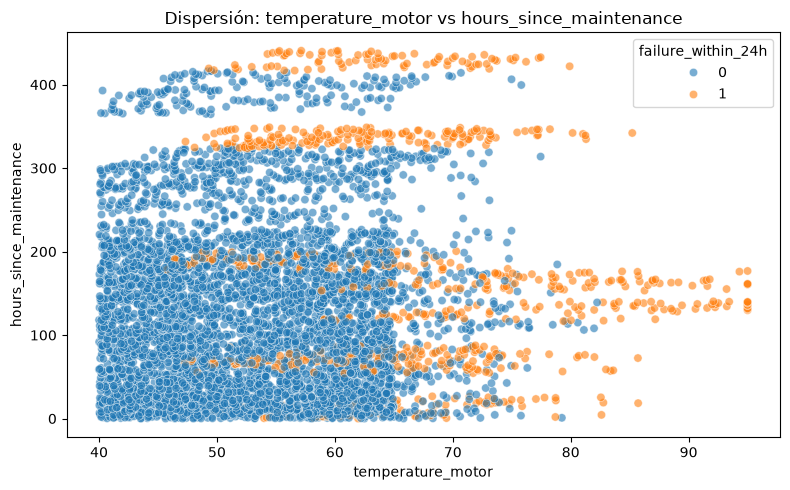

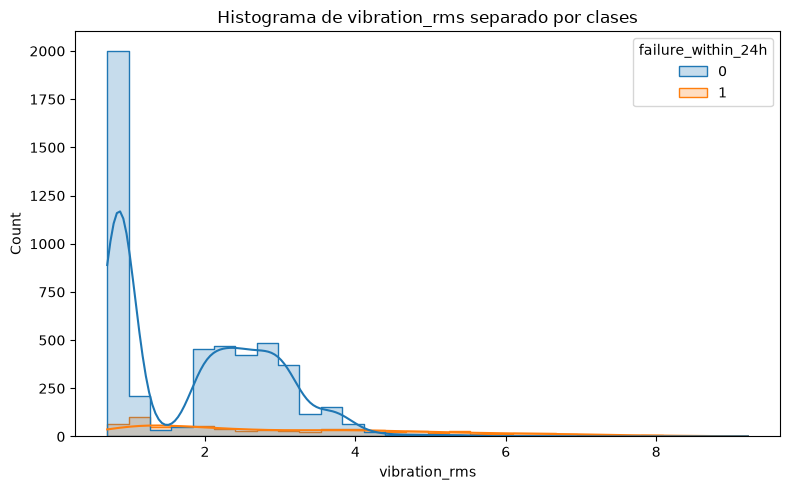

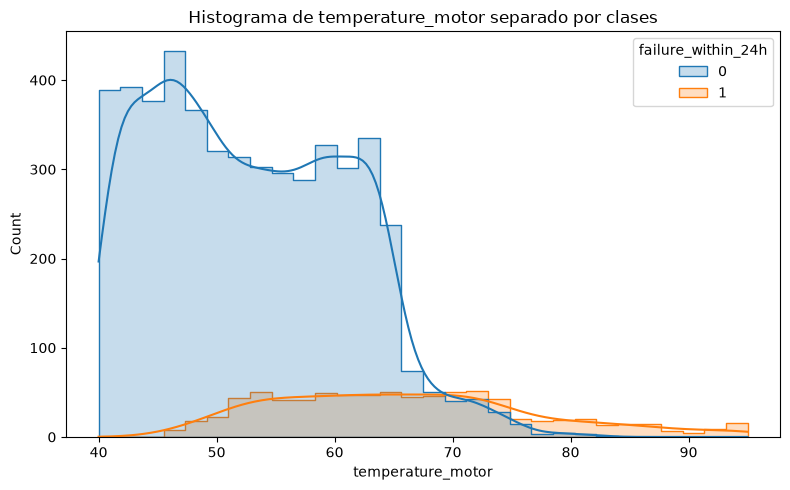

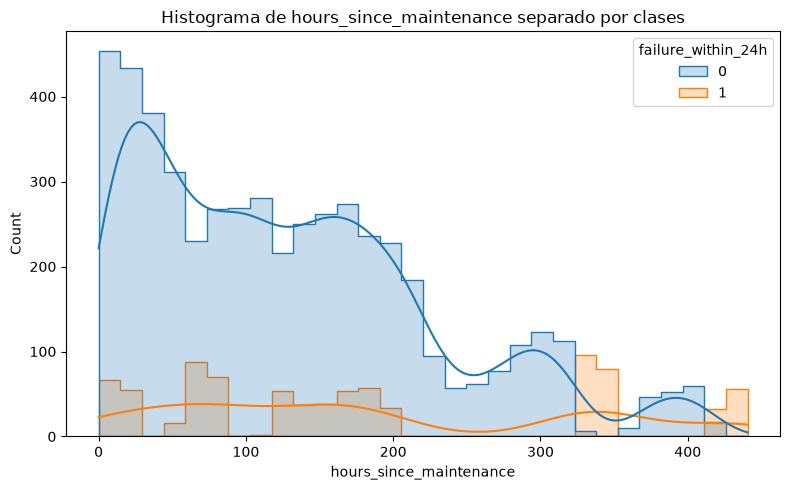

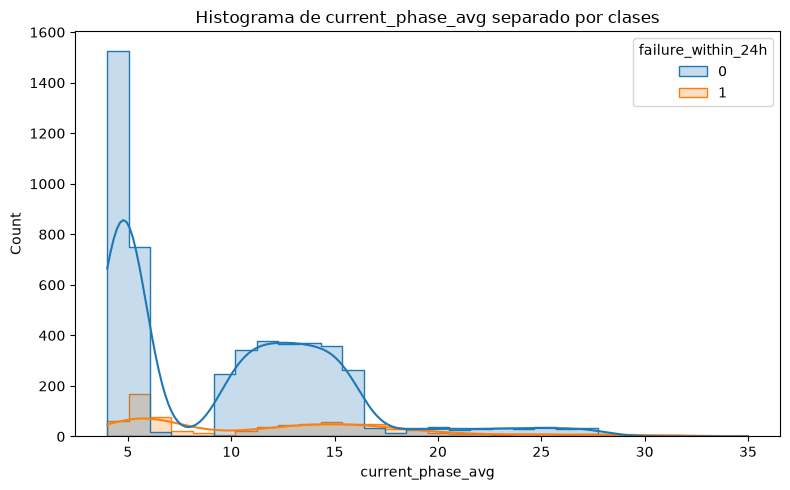

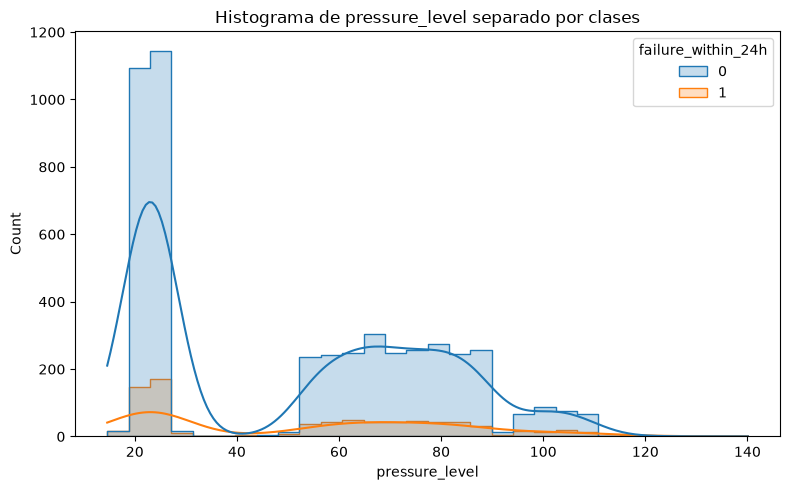

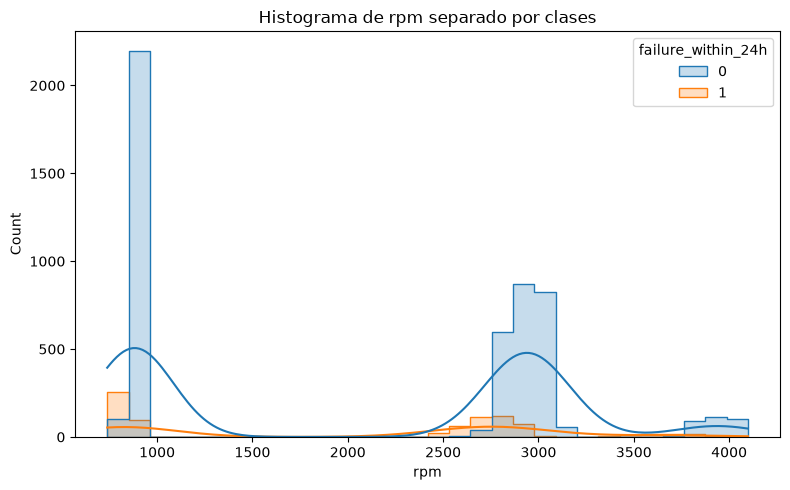


================ MÉTRICAS DEL MODELO ================
Accuracy:  0.8906
Precision: 0.7391
Recall:    0.3400
F1-score:  0.4658
AUC:       0.8347
MCC:       0.4529

Matriz de confusión:


array([[1502,   30],
       [ 165,   85]])


Classification report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1532
           1       0.74      0.34      0.47       250

    accuracy                           0.89      1782
   macro avg       0.82      0.66      0.70      1782
weighted avg       0.88      0.89      0.87      1782


Log-verosimilitud: -524.5811
Entropía de Shannon media: 0.4222

Coeficientes del modelo:


'temperature_motor: 1.3812'

'vibration_rms: 0.0869'

'hours_since_maintenance: 0.5017'

Intercepto: -2.5001


In [2]:

# load and keep only CNC
df = pd.read_csv("predictive_maintenance_v3.csv")
df = df[df["machine_type"] == "CNC"].copy()

# remove certain variables that are noise and do not influence
# machine_id, timestamp, estimated_repair_cost, operating_mode,
# machine_type, failure_type, ambient_temp, rul_hours
cols_drop = [
    "machine_id",
    "timestamp",
    "estimated_repair_cost",
    "operating_mode",
    "machine_type",
    "failure_type",
    "ambient_temp",
    "rul_hours"
]
df = df.drop(columns=cols_drop)

# initial exploratory analysis
print("Dataset shape after filtering CNC and removing columns:", df.shape)
print("\nAvailable columns:")
print(df.columns.tolist())

print("\nNull value counts by column:")
print(df.isnull().sum())

print("\nDescriptive statistics:")
print(df.describe())

# correlation matrix
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation heatmap - CNC machines")
plt.tight_layout()
plt.show()

# scatter plots
pairs = [
    ("vibration_rms", "temperature_motor"),
    ("vibration_rms", "hours_since_maintenance"),
    ("temperature_motor", "hours_since_maintenance")
]

for x_var, y_var in pairs:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=x_var, y=y_var, hue="failure_within_24h", alpha=0.6)
    plt.title(f"Scatter: {x_var} vs {y_var}")
    plt.tight_layout()
    plt.show()

# histograms by class
vars_hist = ["vibration_rms", "temperature_motor", "hours_since_maintenance", "current_phase_avg", "pressure_level", "rpm"]

for var in vars_hist:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=var, hue="failure_within_24h", kde=True, bins=30, element="step")
    plt.title(f"Histogram of {var} separated by class")
    plt.tight_layout()
    plt.show()

# final variables
features = ["temperature_motor", "vibration_rms", "hours_since_maintenance"]
target = "failure_within_24h"

X = df[features].copy()
y = df[target].astype(int).copy()

# train 70 test 30

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# MODEL PIPELINE: STANDARD SCALER + KNN IMPUTER + LOGISTIC REGRESSION

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("imputer", KNNImputer(n_neighbors=5)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

pipeline.fit(X_train, y_train)

# predictions and immediate metrics
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)
mcc = matthews_corrcoef(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n================ MODEL METRICS ================")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")
print(f"MCC:       {mcc:.4f}")

print("\nConfusion matrix:")
display(cm)

print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

# log-likelihood
# calculated as the negative of log_loss (which is what Orange offers) multiplied by n
eps = 1e-15
y_prob_clip = np.clip(y_prob, eps, 1 - eps)
log_verosimilitud = np.sum(
    y_test * np.log(y_prob_clip) + (1 - y_test) * np.log(1 - y_prob_clip)
)
print(f"\nLog-likelihood: {log_verosimilitud:.4f}")


# Shannon entropy as the mean of entropies
# we could also calculate the entropy of the mean of probabilities, it would be different
probs_bin = np.vstack([1 - y_prob_clip, y_prob_clip]).T
entropias = np.array([entropy(p, base=2) for p in probs_bin])
entropia_media = entropias.mean()
print(f"Mean Shannon entropy: {entropia_media:.4f}")

# logistic regression coefficients 
coeficientes = pipeline.named_steps["model"].coef_[0]
intercepto = pipeline.named_steps["model"].intercept_[0]

print("\nModel coefficients:")
for var, coef in zip(features, coeficientes):
    display(f"{var}: {coef:.4f}")
print(f"Intercept: {intercepto:.4f}")